In [340]:
import pandas as pd
import numpy as np

*Import the dataset*

In [341]:
df = pd.read_csv(r"C:\Users\Vismaya\Downloads\customer_data.csv")

 *Create a copy of original dataset so that i don't lose the raw data*

In [342]:
raw_df = df.copy()

In [343]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       50501 non-null  str    
 1   Name             51000 non-null  str    
 2   Age              48417 non-null  float64
 3   Gender           36365 non-null  str    
 4   Country          38330 non-null  str    
 5   SignupDate       49957 non-null  str    
 6   LastLogin        49939 non-null  str    
 7   TotalPurchase    48601 non-null  float64
 8   PreferredDevice  33878 non-null  str    
 9   Email            49696 non-null  str    
dtypes: float64(2), str(8)
memory usage: 3.9 MB


In [344]:
print(df.describe(include='all'))

                                  CustomerID           Name           Age  \
count                                  50501          51000  48417.000000   
unique                                 49511          40745           NaN   
top     753c7c99-032f-46ca-b0d9-c2aa8f837ef7  Michael Smith           NaN   
freq                                       2             23           NaN   
mean                                     NaN            NaN     51.410414   
std                                      NaN            NaN     31.253474   
min                                      NaN            NaN     -5.000000   
25%                                      NaN            NaN     32.000000   
50%                                      NaN            NaN     49.000000   
75%                                      NaN            NaN     66.000000   
max                                      NaN            NaN    200.000000   

        Gender Country  SignupDate   LastLogin  TotalPurchase PreferredDevi

In [345]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       50501 non-null  str    
 1   Name             51000 non-null  str    
 2   Age              48417 non-null  float64
 3   Gender           36365 non-null  str    
 4   Country          38330 non-null  str    
 5   SignupDate       49957 non-null  str    
 6   LastLogin        49939 non-null  str    
 7   TotalPurchase    48601 non-null  float64
 8   PreferredDevice  33878 non-null  str    
 9   Email            49696 non-null  str    
dtypes: float64(2), str(8)
memory usage: 3.9 MB


## EDA

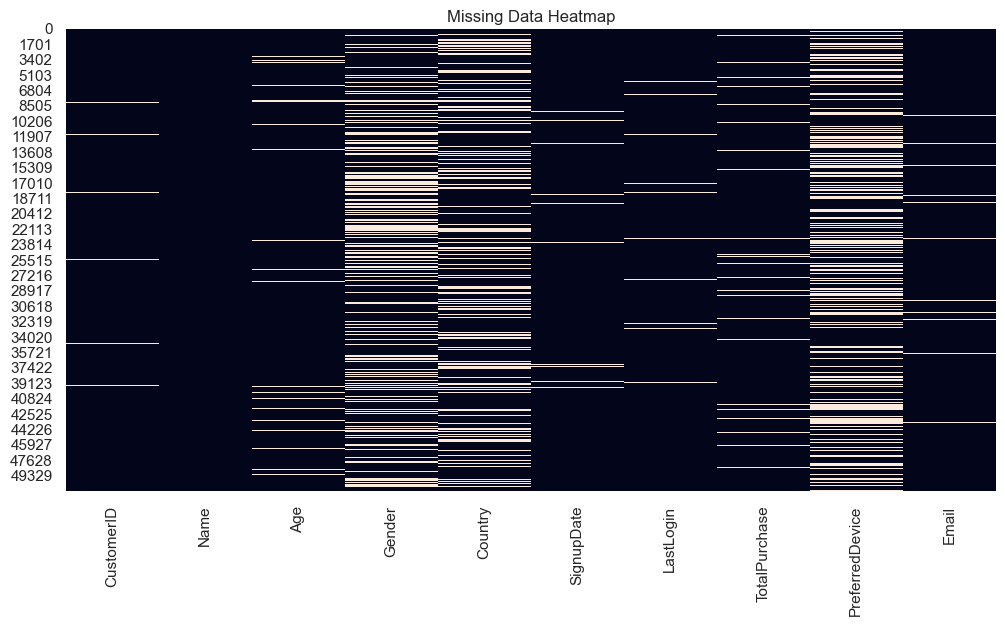

In [346]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(raw_df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

In [347]:
full_row_dups = df[df.duplicated(keep=False)]

print("Number of fully duplicated rows:", df.duplicated().sum())
full_row_dups.head()

Number of fully duplicated rows: 1000


,CustomerID,Name,Age,Gender,Country,SignupDate,LastLogin,TotalPurchase,PreferredDevice,Email
85,753c7c99-032f-46ca-b0d9-c2aa8f837ef7,Yolanda Rich,38.0,NaN,NaN,2022-03-19,2025-02-07,5950.44,moblie,@example.com
92,bf9cc545-6355-48f7-8f6f-a985b732d46f,7605,38.0,Unknown,USA,2023-03-10,2024-12-31,581.38,NaN,franciscokhan@miller.info
108,f689a4a5-ffda-4336-8c6e-90373020da5c,Mason Diaz,60.0,Femlae,Indai,2023-05-17,2023-09-30,1779.16,moblie,katie45@gmail.com
121,41a93f90-dc82-4527-9da3-b7e2cad6e514,8588,24.0,NaN,India,2022-05-15,2023-06-03,5177.85,dasktop,vfreeman@gmail.com
391,f57b8a92-0a12-43b3-a4fc-0dbad44f85e7,Gary Grimes,79.0,Femlae,NaN,2022-03-19,2024-12-24,5279.34,desktop,marcus70@hatfield-moyer.com


In [348]:
difference_columns = full_row_dups.nunique() != 1
difference_columns

CustomerID         True
Name               True
Age                True
Gender             True
Country            True
SignupDate         True
LastLogin          True
TotalPurchase      True
PreferredDevice    True
Email              True
dtype: bool

In [349]:
(df.duplicated().sum() == len(full_row_dups) / 2) or (df.duplicated().sum() == len(full_row_dups))

np.True_

In [350]:
df = df.drop_duplicates()

In [351]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       49511 non-null  str    
 1   Name             50000 non-null  str    
 2   Age              47462 non-null  float64
 3   Gender           35667 non-null  str    
 4   Country          37563 non-null  str    
 5   SignupDate       48976 non-null  str    
 6   LastLogin        48963 non-null  str    
 7   TotalPurchase    47640 non-null  float64
 8   PreferredDevice  33217 non-null  str    
 9   Email            48730 non-null  str    
dtypes: float64(2), str(8)
memory usage: 3.8 MB


In [352]:
sns.set(style="whitegrid")

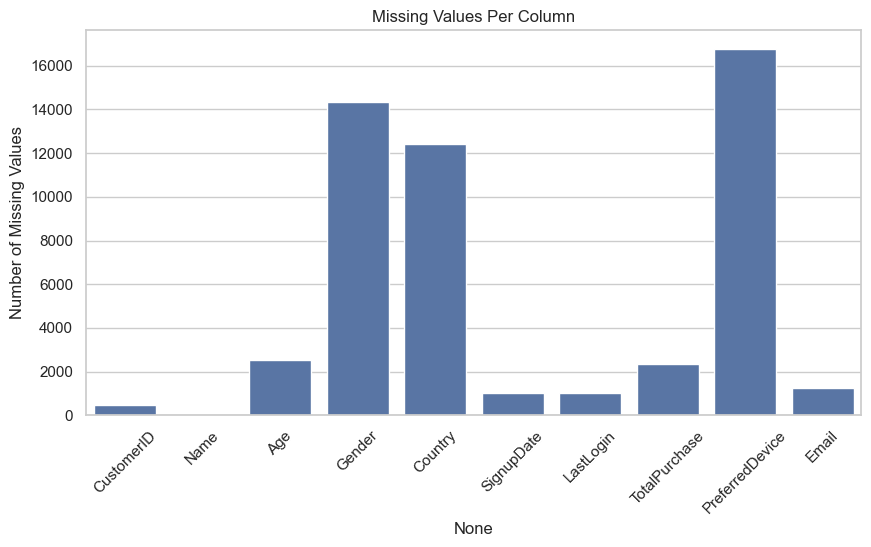

In [353]:
plt.figure(figsize=(10,5))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.title('Missing Values Per Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation = 45)
plt.show()

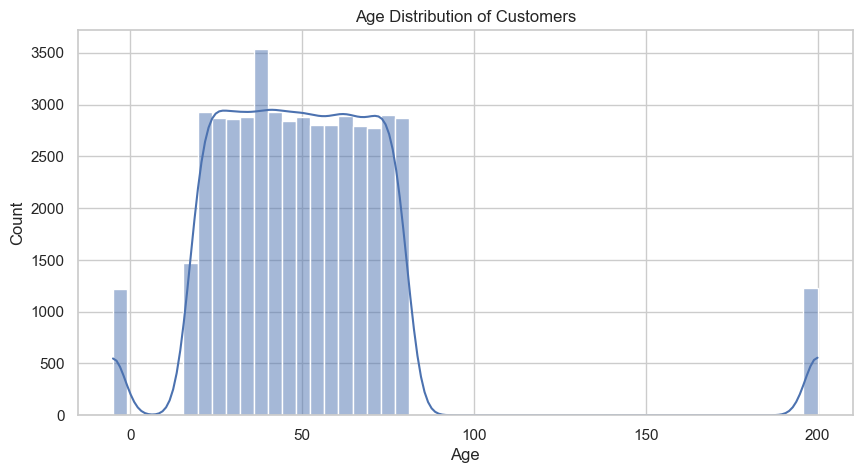

In [354]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), bins=50, kde=True)
plt.title("Age Distribution of Customers")
plt.show()

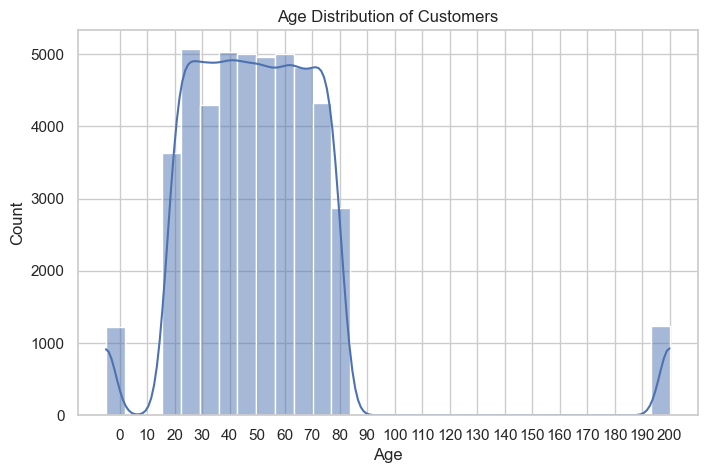

In [355]:
max_age = int(df['Age'].max())

plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.xticks(range(0, max_age + 5, 10))

plt.show()


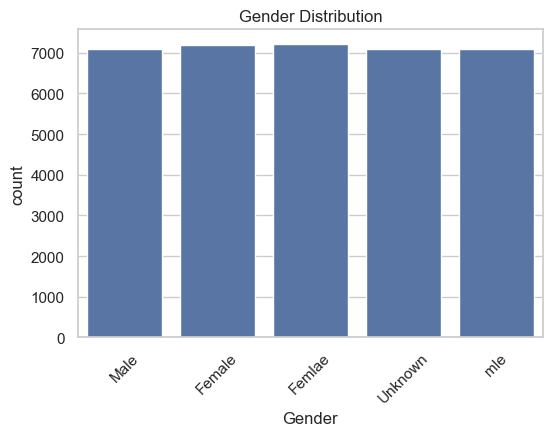

In [356]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Gender'])
plt.title("Gender Distribution")
plt.xticks(rotation=45)
plt.show()

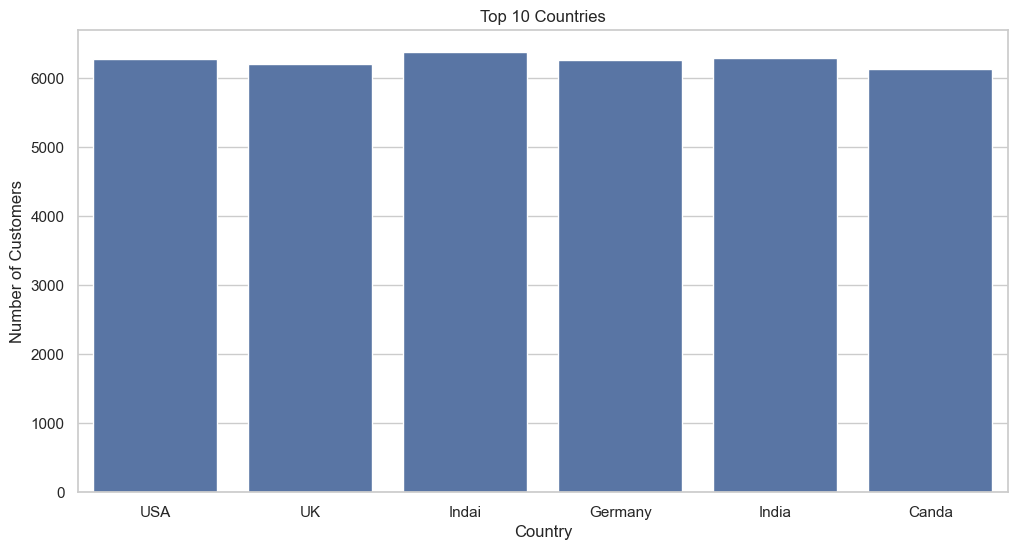

In [357]:
plt.figure(figsize=(12, 6))
sns.countplot(x=df['Country'])
plt.title("Top 10 Countries")
plt.ylabel("Number of Customers")
plt.show()

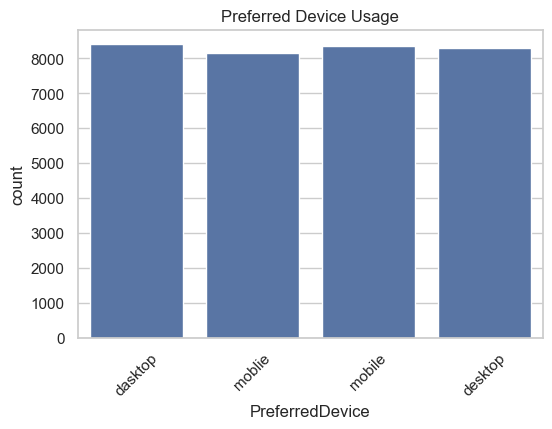

In [358]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['PreferredDevice'])
plt.title("Preferred Device Usage")
plt.xticks(rotation=45)
plt.show()

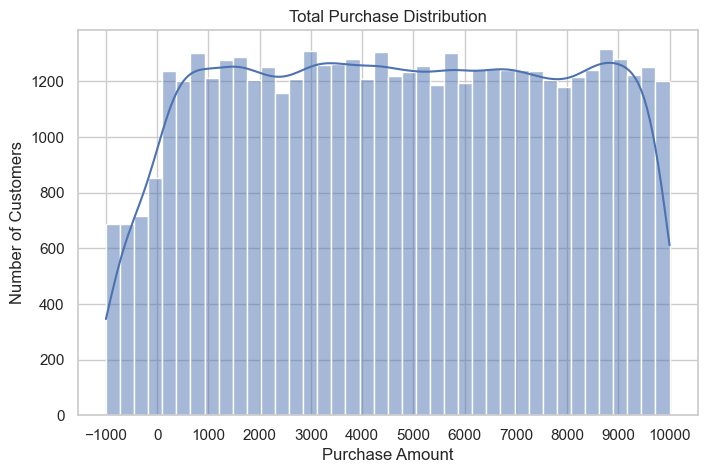

In [359]:
max_purchase = int(df['TotalPurchase'].max())
plt.figure(figsize=(8,5))
sns.histplot(df['TotalPurchase'].dropna(), bins=40, kde=True)
plt.title("Total Purchase Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Customers")
plt.xticks(range(-1000, max_purchase + 10, 1000))
plt.show()

## Summary of EDA

### Missing Data
- *The dataset contains 51,000 entries with many columns having a large number of missing values.*
- *the missing data heatmap clearly shows that missing values are not uniformly distributed across columns.*
- *i.e. Columns such as Preferred Device, Gender, and Country have more missing values, while other columns have comparatively less missing values.*
- *Hence we need a column-wise strategy for missing value handling rather than a single global strategy.*

### Duplicates
- *There are 1000 rows of duplicate found in the dataset, hence these duplicates has to be removed*
- *After removing duplicates, the dataset size reduced to 50,000 entries.*

### Age
- *The age distribution has some invalid values, including negative ages and unrealistically high ages (e.g., ~200 years), which are not logically possible.*
- *These values need to be either corrected or removed.*

### Gender, Country and Preferred Device 
- *The gender distribution has some inconsistent category labels because of spelling mistakes (e.g., "mle" instead of "male").*

- *Similar spelling inconsistencies were observed in the Country and Preferred Device columns (e.g., same country/device appearing under multiple names).*
- *Hence these inconsistencies has to be normalized.*

### Purchase Distribution
- *Total purchase distribution plot showed some unrealistic range for purchase amount such as negative amount, which needs to be clipped and cleaned.*

In [360]:
df['Gender'].head(25)

0        Male
1      Female
2      Femlae
3     Unknown
4         NaN
5         NaN
6      Female
7     Unknown
8         NaN
9         mle
10    Unknown
11        NaN
12     Female
13       Male
14        NaN
15    Unknown
16     Femlae
17        NaN
18        NaN
19    Unknown
20        NaN
21        NaN
22    Unknown
23        NaN
24        NaN
Name: Gender, dtype: str

In [361]:
df['Gender'] = df['Gender'].replace({'mle' : 'Male', 'Femlae' : 'Female'})
df['Gender'] = df['Gender'].fillna("Unknown")
df['Gender'] = df['Gender'].replace("Unknown", "Unspecified")
print(df['Gender'].value_counts())

Gender
Unspecified    21426
Female         14397
Male           14177
Name: count, dtype: int64


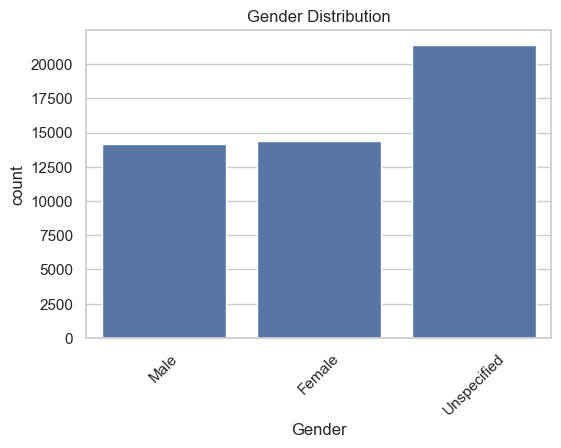

In [362]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Gender'])
plt.title("Gender Distribution")
plt.xticks(rotation=45)
plt.show()

In [363]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       49511 non-null  str    
 1   Name             50000 non-null  str    
 2   Age              47462 non-null  float64
 3   Gender           50000 non-null  str    
 4   Country          37563 non-null  str    
 5   SignupDate       48976 non-null  str    
 6   LastLogin        48963 non-null  str    
 7   TotalPurchase    47640 non-null  float64
 8   PreferredDevice  33217 non-null  str    
 9   Email            48730 non-null  str    
dtypes: float64(2), str(8)
memory usage: 3.8 MB


In [364]:
raw_df.to_csv("customer_data_raw_backup.csv", index=False)

In [365]:
print(df.shape)
print(raw_df.shape)

(50000, 10)
(51000, 10)


In [366]:
print(df['Country'].value_counts(dropna=False))

Country
NaN        12437
Indai       6377
India       6293
USA         6285
Germany     6266
UK          6202
Canda       6140
Name: count, dtype: int64


In [367]:
df['Country'] = df['Country'].replace({'Indai' : 'India', 'Canda' : 'Canada'})
df['Country'] = df['Country'].fillna("Unknown")
print(df['Country'].value_counts())

Country
India      12670
Unknown    12437
USA         6285
Germany     6266
UK          6202
Canada      6140
Name: count, dtype: int64


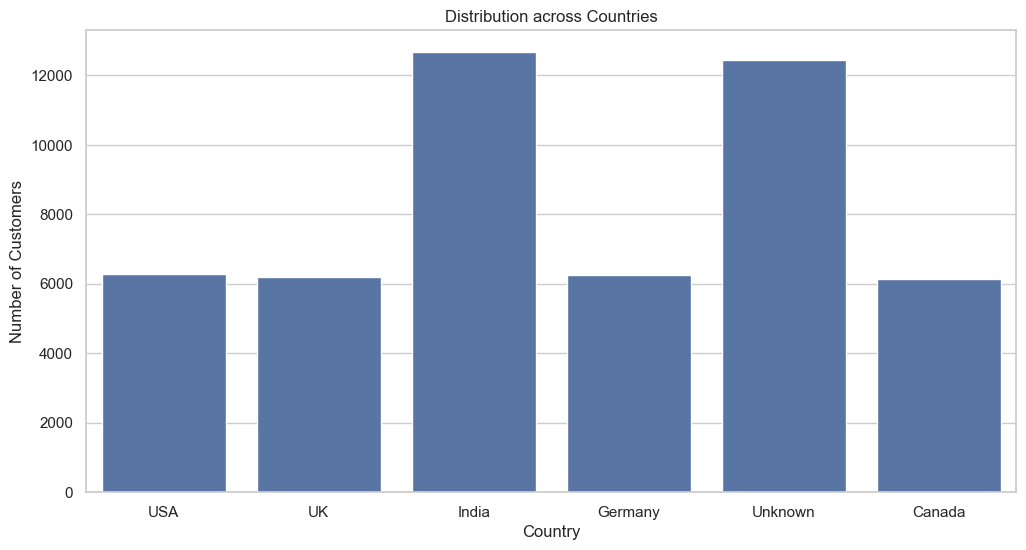

In [368]:
plt.figure(figsize=(12, 6))
sns.countplot(x=df['Country'])
plt.title("Distribution across Countries")
plt.ylabel("Number of Customers")
plt.show()

In [369]:
print(df['PreferredDevice'].value_counts(dropna=False))

PreferredDevice
NaN        16783
dasktop     8406
mobile      8343
desktop     8305
moblie      8163
Name: count, dtype: int64


In [370]:
df['PreferredDevice'] = df['PreferredDevice'].replace({'dasktop' : 'Desktop',
                                                       'mobile' : 'Mobile',
                                                       'moblie' : 'Mobile',
                                                       'desktop' : 'Desktop'})
df['PreferredDevice'] = df['PreferredDevice'].fillna("Unknown")
print(df['PreferredDevice'].value_counts())

PreferredDevice
Unknown    16783
Desktop    16711
Mobile     16506
Name: count, dtype: int64


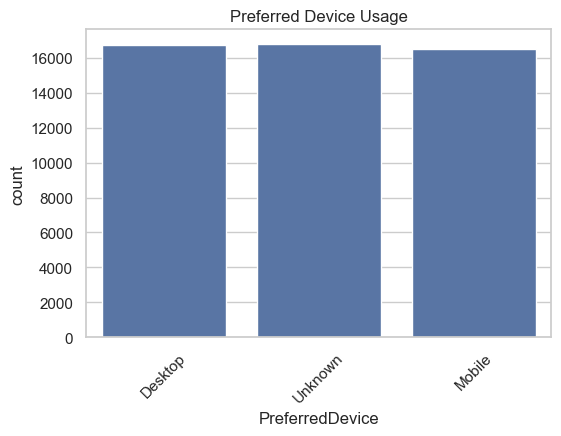

In [371]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['PreferredDevice'])
plt.title("Preferred Device Usage")
plt.xticks(rotation=45)
plt.show()

In [372]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       49511 non-null  str    
 1   Name             50000 non-null  str    
 2   Age              47462 non-null  float64
 3   Gender           50000 non-null  str    
 4   Country          50000 non-null  str    
 5   SignupDate       48976 non-null  str    
 6   LastLogin        48963 non-null  str    
 7   TotalPurchase    47640 non-null  float64
 8   PreferredDevice  50000 non-null  str    
 9   Email            48730 non-null  str    
dtypes: float64(2), str(8)
memory usage: 3.8 MB


In [373]:
# Count invalid ages
invalid_ages = df[(df['Age'] < 18) | (df['Age'] > 100)]
print("Number of invalid ages:", len(invalid_ages))

Number of invalid ages: 2447


In [374]:
# Replace invalid ages (<18 or >100) with NaN
df['Age'] = df['Age'].apply(lambda x: x if 18 <= x <= 100 else None)

# Fill Age using median per Gender & Country
df['Age'] = df.groupby(['Gender', 'Country'])['Age'].transform(
    lambda x: x.fillna(x.median()))

# If still missing (due to unknown country/gender), fill with overall median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [375]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       49511 non-null  str    
 1   Name             50000 non-null  str    
 2   Age              50000 non-null  float64
 3   Gender           50000 non-null  str    
 4   Country          50000 non-null  str    
 5   SignupDate       48976 non-null  str    
 6   LastLogin        48963 non-null  str    
 7   TotalPurchase    47640 non-null  float64
 8   PreferredDevice  50000 non-null  str    
 9   Email            48730 non-null  str    
dtypes: float64(2), str(8)
memory usage: 3.8 MB


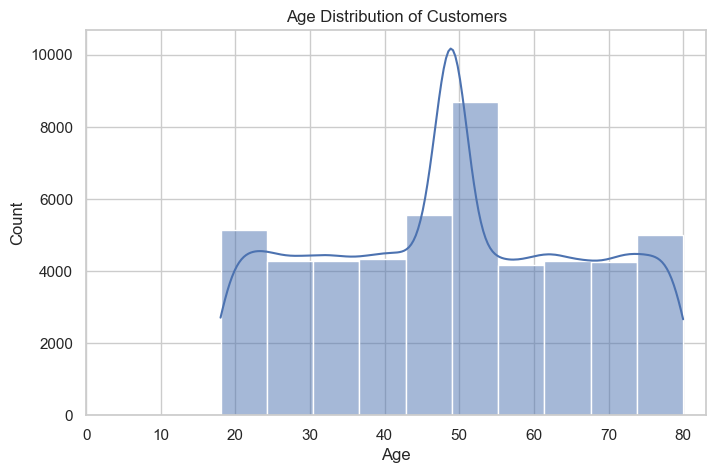

In [376]:
max_age = int(df['Age'].max())

plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), bins=10, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.xticks(range(0, max_age + 5, 10))
plt.show()

In [377]:
print("Missing Age values after filling:", df['Age'].isna().sum())

Missing Age values after filling: 0


In [378]:
df['Age'].head(50)

0     63.0
1     42.0
2     76.0
3     53.0
4     74.0
5     74.0
6     51.0
7     38.0
8     63.0
9     29.0
10    76.0
11    49.0
12    35.0
13    49.0
14    25.0
15    58.0
16    29.0
17    47.0
18    70.0
19    63.0
20    76.0
21    76.0
22    47.0
23    66.0
24    60.0
25    30.0
26    69.0
27    59.0
28    38.0
29    54.0
30    37.0
31    29.0
32    50.0
33    49.0
34    74.0
35    49.0
36    50.0
37    39.0
38    41.0
39    76.0
40    73.0
41    46.0
42    70.0
43    76.0
44    76.0
45    45.0
46    37.0
47    23.0
48    64.0
49    58.0
Name: Age, dtype: float64

In [379]:
df['SignupDate'].head(10)

0    2021-12-22
1    2023-04-21
2    2020-09-16
3    2021-05-16
4    2022-04-14
5    2022-03-09
6    2021-01-16
7    2020-11-26
8    2021-01-07
9    2023-11-14
Name: SignupDate, dtype: str

In [380]:
df['SignupDate'].info()

<class 'pandas.Series'>
RangeIndex: 50000 entries, 0 to 49999
Series name: SignupDate
Non-Null Count  Dtype
--------------  -----
48976 non-null  str  
dtypes: str(1)
memory usage: 390.8 KB


In [381]:
df['SignupDate'] = df['SignupDate'].fillna('')

# Keep original column name but convert valid values to datetime
df['SignupDate'] = pd.to_datetime(df['SignupDate'], errors='coerce')

In [382]:
print(df['SignupDate'].isna().sum())  # Should show 1024 still NaT
print(df['SignupDate'].dtype)        # Should show datetime64

1024
datetime64[us]


In [383]:
df['SignupDate'].info()

<class 'pandas.Series'>
RangeIndex: 50000 entries, 0 to 49999
Series name: SignupDate
Non-Null Count  Dtype         
--------------  -----         
48976 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 390.8 KB


In [384]:
df['LastLogin'].info()

<class 'pandas.Series'>
RangeIndex: 50000 entries, 0 to 49999
Series name: LastLogin
Non-Null Count  Dtype
--------------  -----
48963 non-null  str  
dtypes: str(1)
memory usage: 390.8 KB


In [385]:
print(df['LastLogin'].head(10))
print("Missing LastLogin:", df['LastLogin'].isna().sum())

0    2023-09-12
1    2024-06-28
2    2023-06-13
3    2024-12-15
4    2025-01-08
5    2023-07-13
6    2024-09-23
7    2023-11-21
8    2024-04-16
9    2024-12-15
Name: LastLogin, dtype: str
Missing LastLogin: 1037


In [386]:
# Convert to datetime 
df['LastLogin_converted'] = pd.to_datetime(df['LastLogin'], errors='coerce')

# Count invalid values
print("Invalid dates:", df['LastLogin_converted'].isna().sum())

# Future dates check
future_ll = df[df['LastLogin_converted'] > pd.Timestamp.today()]
print("Future login dates:", len(future_ll))

Invalid dates: 1037
Future login dates: 0


In [387]:
# keep original as datetime
df['LastLogin'] = pd.to_datetime(df['LastLogin'], errors='coerce')

# Create a status label
df['LoginStatus'] = df['LastLogin'].isna().map({True: 'NeverLoggedIn', False: 'Active'})

In [388]:
print(df['LoginStatus'].value_counts())
print(df['LastLogin'].dtype)

LoginStatus
Active           48963
NeverLoggedIn     1037
Name: count, dtype: int64
datetime64[us]


In [389]:
print("Total Purchase Missing Values:", df['TotalPurchase'].isna().sum())
print("Invalid (negative):", (df['TotalPurchase'] < 0).sum())

# Check for outliers
print("\nTop 10 highest purchases:")
print(df['TotalPurchase'].nlargest(10))

Total Purchase Missing Values: 2360
Invalid (negative): 2516

Top 10 highest purchases:
28238    9999.58
19577    9999.30
39612    9999.07
39824    9998.89
31771    9998.65
42149    9998.52
17914    9998.25
6923     9998.23
27157    9997.74
11371    9997.40
Name: TotalPurchase, dtype: float64


In [390]:
# Check for negative amounts
negatives = df[df['TotalPurchase'] < 0]
print("Count of negatives:", len(negatives))

negatives.head(10)

Count of negatives: 2516


,CustomerID,Name,Age,Gender,Country,SignupDate,LastLogin,TotalPurchase,PreferredDevice,Email,LastLogin_converted,LoginStatus
31,8c1745a7-9a6a-4f92-8ca7-4147f6be1f72,Justin Morris,29.0,Female,USA,2020-08-11,2025-03-03,-676.59,Mobile,joshua70@anderson.com,2025-03-03,Active
87,2284b7a4-47e7-4593-8b58-85ca0bb2c3f0,Cynthia Shaw,29.0,Unspecified,Germany,2023-03-10,2023-12-23,-794.26,Desktop,karen68@hernandez-bennett.org,2023-12-23,Active
98,df26f517-66fa-4989-8813-5d586a1689ad,Carolyn Martin,46.0,Unspecified,Unknown,2022-05-31,2024-05-07,-269.98,Unknown,alexanderkaitlyn@hotmail.com,2024-05-07,Active
107,6a46721a-cffa-4cdd-b963-a7efe00111e5,Karen Holden,43.0,Unspecified,India,2023-09-25,2024-12-24,-339.87,Desktop,hawkinstammy@yahoo.com,2024-12-24,Active
117,2ea60b99-fa7f-48bf-b044-284a47acf2f6,Ruth Henry,74.0,Unspecified,Canada,2023-09-04,2024-10-20,-370.87,Desktop,pbrewer@yahoo.com,2024-10-20,Active
149,09aedbd0-6d31-4b4a-bf6b-8793b318ad4c,Sara Coleman,44.0,Female,Canada,2023-06-16,2024-05-25,-729.58,Desktop,chaneykelly@yahoo.com,2024-05-25,Active
198,6af79ad2-993e-48c6-a6b1-06e289110af0,Rebekah Harvey,41.0,Unspecified,USA,2022-01-31,2023-11-15,-546.88,Mobile,invalidemail.com,2023-11-15,Active
230,fbbff9e0-ae56-402a-b521-ca9fdf5e6f78,Mr. James Greene,25.0,Female,India,2022-01-10,2024-01-21,-122.12,Unknown,reginald27@cervantes.info,2024-01-21,Active
304,ab2212c9-e23b-480e-8523-dbbb1eeed219,Bonnie Barajas,70.0,Unspecified,UK,2024-04-03,2024-05-20,-943.25,Desktop,ryan29@hayes-mitchell.com,2024-05-20,Active
338,a3ef802e-df86-43ce-8534-32cdffeb5d5f,Troy Long,80.0,Male,USA,2021-11-11,2024-05-13,-731.07,Mobile,taylorjennifer@gmail.com,2024-05-13,Active


In [391]:
# Fix negative purchase amounts by converting to positive
df['TotalPurchase'] = df['TotalPurchase'].abs()

# Now fill missing values with median (more robust than mean)
median_purchase = df['TotalPurchase'].median()
df['TotalPurchase'] = df['TotalPurchase'].fillna(median_purchase)

print("Remaining missing:", df['TotalPurchase'].isna().sum())

Remaining missing: 0


In [392]:
df['TotalPurchase'].head(10)

0    2141.15
1    2863.67
2    2427.18
3    5986.07
4    3374.72
5     740.75
6    7702.33
7    5103.92
8    1666.40
9    7062.40
Name: TotalPurchase, dtype: float64

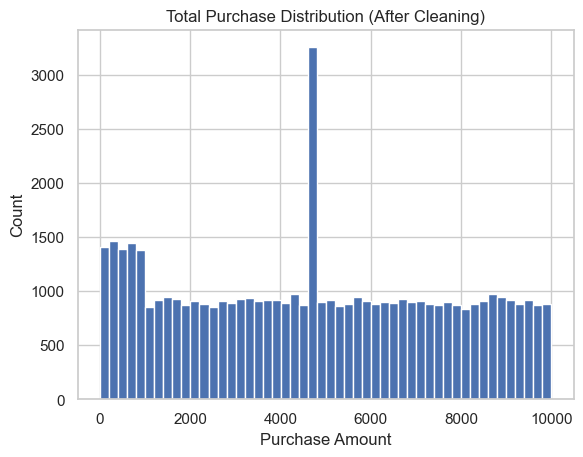

In [393]:
df['TotalPurchase'].hist(bins=50)
plt.title("Total Purchase Distribution (After Cleaning)")
plt.xlabel("Purchase Amount")
plt.ylabel("Count")
plt.show()


In [394]:
df.head()

,CustomerID,Name,Age,Gender,Country,SignupDate,LastLogin,TotalPurchase,PreferredDevice,Email,LastLogin_converted,LoginStatus
0,e3e70682-c209-4cac-a29f-6fbed82c07cd,Christopher Williams,63.0,Male,USA,2021-12-22,2023-09-12,2141.15,Desktop,margaret03@bullock.info,2023-09-12,Active
1,f728b4fa-4248-4e3a-8a5d-2f346baa9455,Kevin Hopkins,42.0,Female,UK,2023-04-21,2024-06-28,2863.67,Unknown,tammy76@mcintyre.org,2024-06-28,Active
2,eb1167b3-67a9-4378-bc65-c1e582e2e662,Sonya Stafford,76.0,Female,UK,2020-09-16,2023-06-13,2427.18,Unknown,lauramichael@hotmail.com,2023-06-13,Active
3,f7c1bd87-4da5-4709-9471-3d60c8a70639,Matthew Schmidt,53.0,Unspecified,India,2021-05-16,2024-12-15,5986.07,Mobile,@example.com,2024-12-15,Active
4,e443df78-9558-467f-9ba9-1faf7a024204,Kristen Banks,74.0,Unspecified,UK,2022-04-14,2025-01-08,3374.72,Desktop,blacknicole@smith-lewis.com,2025-01-08,Active


In [395]:
df['Name'].head(10)

0    Christopher Williams
1           Kevin Hopkins
2          Sonya Stafford
3         Matthew Schmidt
4           Kristen Banks
5            Andrew Adams
6                    7061
7          Amanda Webster
8              David Holt
9        Cameron Guerrero
Name: Name, dtype: str

In [396]:
print("Unique names:", df['Name'].nunique())
print("Total rows:", len(df))

# Check names that contains numbers or symbols
print("Names with numbers:", df['Name'].str.contains(r"[0-9]", regex=True).sum())
print("Names with special chars (excluding hyphen & apostrophe):",
      df['Name'].str.contains(r"[^a-zA-Z\s\-\']", regex=True).sum())


Unique names: 40745
Total rows: 50000
Names with numbers: 2443
Names with special chars (excluding hyphen & apostrophe): 3430


In [397]:
df['Name'] = df['Name'].str.strip()

In [398]:
df['Name'] = df['Name'].str.replace(r"[0-9]", '', regex=True).str.strip()
df['Name'] = df['Name'].replace('', np.nan)

In [399]:
df['Name'] = df['Name'].str.title().str.replace("'S", "'s", regex=True)

In [400]:
df['Name'].isna().sum()

np.int64(2443)

In [401]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           49511 non-null  str           
 1   Name                 47557 non-null  str           
 2   Age                  50000 non-null  float64       
 3   Gender               50000 non-null  str           
 4   Country              50000 non-null  str           
 5   SignupDate           48976 non-null  datetime64[us]
 6   LastLogin            48963 non-null  datetime64[us]
 7   TotalPurchase        50000 non-null  float64       
 8   PreferredDevice      50000 non-null  str           
 9   Email                48730 non-null  str           
 10  LastLogin_converted  48963 non-null  datetime64[us]
 11  LoginStatus          50000 non-null  str           
dtypes: datetime64[us](3), float64(2), str(7)
memory usage: 4.6 MB


In [402]:
print("Unique names:", df['Name'].nunique())
print("Total rows:", len(df))
print("Names with numbers:", df['Name'].str.contains(r'\d').sum())
print("Special chars:", df['Name'].str.contains(r"[^a-zA-Z\s'-]").sum())

Unique names: 38610
Total rows: 50000
Names with numbers: 0
Special chars: 987


In [403]:
special_char_names = df[df['Name'].str.contains(r"[^a-zA-Z\s'-]", na=False)]

In [404]:
special_char_names['Name'].head(20)

50         Mrs. Natalie Moreno
68         Mr. Anthony Wong Md
116        Dr. Brittany Martin
133         Mrs. Sandra Obrien
144       Mrs. Jocelyn Collins
160             Dr. Paul Oneal
227        Ms. Laura Brown Phd
230           Mr. James Greene
262          Mrs. Katrina Reed
284       Mrs. Mary Parker Phd
288           Mr. Todd Koch Md
423         Mr. Timothy Miller
516    Mr. Christopher Spencer
519    Mrs. Sabrina Snyder Dds
525     Mr. Daniel Russell Jr.
610           Stephen Tran Jr.
619           Ms. Gloria Mckee
622    Mrs. Alexandra Thompson
769      Mr. Zachary Hendricks
792             John Wells Jr.
Name: Name, dtype: str

In [405]:
print("Missing names:", df['Name'].isna().sum())

Missing names: 2443


In [406]:
# remove titles from names
df['Name'] = df['Name'].str.replace(r'\b(Mr|Mrs|Ms|Dr|Prof|Miss|Sir)\.?\b','',
    regex=True,
    case=False
)

# Remove all other characters expect Alphabets
df['Name'] = df['Name'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

# Remove extra spaces
df['Name'] = df['Name'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Keep only first and last name
df['Name'] = df['Name'].apply(
    lambda x: ' '.join(x.split()[:2]) if isinstance(x, str) else x
)

# Standardize casing
df['Name'] = df['Name'].str.title()

In [407]:
df['Name'].head()

0    Christopher Williams
1           Kevin Hopkins
2          Sonya Stafford
3         Matthew Schmidt
4           Kristen Banks
Name: Name, dtype: str

In [408]:
df['Name'] = df['Name'].fillna('Unknown')

In [409]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           49511 non-null  str           
 1   Name                 50000 non-null  str           
 2   Age                  50000 non-null  float64       
 3   Gender               50000 non-null  str           
 4   Country              50000 non-null  str           
 5   SignupDate           48976 non-null  datetime64[us]
 6   LastLogin            48963 non-null  datetime64[us]
 7   TotalPurchase        50000 non-null  float64       
 8   PreferredDevice      50000 non-null  str           
 9   Email                48730 non-null  str           
 10  LastLogin_converted  48963 non-null  datetime64[us]
 11  LoginStatus          50000 non-null  str           
dtypes: datetime64[us](3), float64(2), str(7)
memory usage: 4.6 MB


In [410]:
# Convert the datatype of CustomerID to string
df['CustomerID'] = df['CustomerID'].astype(str).str.strip() 

# replace empty CustomerId with NaN values
df.loc[df['CustomerID'] == '', 'CustomerID'] = np.nan

In [411]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           49511 non-null  str           
 1   Name                 50000 non-null  str           
 2   Age                  50000 non-null  float64       
 3   Gender               50000 non-null  str           
 4   Country              50000 non-null  str           
 5   SignupDate           48976 non-null  datetime64[us]
 6   LastLogin            48963 non-null  datetime64[us]
 7   TotalPurchase        50000 non-null  float64       
 8   PreferredDevice      50000 non-null  str           
 9   Email                48730 non-null  str           
 10  LastLogin_converted  48963 non-null  datetime64[us]
 11  LoginStatus          50000 non-null  str           
dtypes: datetime64[us](3), float64(2), str(7)
memory usage: 4.6 MB


In [412]:
df['Email'] = df['Email'].str.strip()
df.loc[df['Email'] == '', 'Email'] = np.nan

In [413]:
# Count rows before drop
initial_rows = len(df)

# Condition: Name + Email + CustomerID are all missing
condition = df['Name'].isna() & df['Email'].isna() & df['CustomerID'].isna()

# Drop those rows
df = df[~condition]

# Show how many dropped
dropped_rows = initial_rows - len(df)
print("Rows dropped (Missing Name + Email + ID):", dropped_rows)


Rows dropped (Missing Name + Email + ID): 0


In [414]:
df['Email'].head(50)

0           margaret03@bullock.info
1              tammy76@mcintyre.org
2          lauramichael@hotmail.com
3                      @example.com
4       blacknicole@smith-lewis.com
5             james83@henderson.com
6               woodsusan@yahoo.com
7               jason95@collins.com
8             tammythomas@brown.org
9             murraydylan@gmail.com
10         reginafrancis@morris.biz
11            rogerslance@gmail.com
12            diazbrian@hotmail.com
13              davidking@gmail.com
14    shelby04@lucero-petersen.info
15             zhernandez@gmail.com
16           hollyleonard@yahoo.com
17                 hperez@jones.com
18             lancepayne@yahoo.com
19                              NaN
20            millerholly@smith.biz
21          kimberlyadams@riley.com
22      adammclean@wood-wilson.info
23                ibush@hotmail.com
24           greenbrenda@martin.com
25         suzanne11@hutchinson.com
26            ypena@gray-holmes.org
27               vwells@cast

In [415]:
# Normalize formatting
df['Email'] = df['Email'].astype(str).str.strip().str.lower()

# Handle missing username before '@'
mask_missing_username = df['Email'].str.startswith('@')
df.loc[mask_missing_username, 'Email'] = (
    'unknown_' + df.index.astype(str) + df['Email']
)

# If email contains '@' but no domain, add placeholder
mask_no_domain = df['Email'].str.contains('@') & df['Email'].str.endswith('@')
df.loc[mask_no_domain, 'Email'] = (
    df['Email'].str[:-1] + '@unknown.com'
)

# Replace emails that are "nan" strings → actual NaN
df['Email'] = df['Email'].replace('nan', np.nan)

# Detect and flag emails still syntactically invalid
email_pattern = r'^[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}$'
df['EmailValid'] = df['Email'].str.match(email_pattern, na=False)



In [416]:
df['EmailValid'].value_counts()
df[df['EmailValid'] == False].head()

,CustomerID,Name,Age,Gender,Country,SignupDate,LastLogin,TotalPurchase,PreferredDevice,Email,LastLogin_converted,LoginStatus,EmailValid
19,a0116be5-ab0c-4681-88f8-e3d0d3290a4c,George Moore,63.0,Unspecified,USA,2022-09-11,2024-07-03,8494.35,Desktop,NaN,2024-07-03,Active,False
43,85940927-468f-453d-864a-7a50b48d73f1,Brandon Petersen,76.0,Unspecified,India,2021-03-23,2024-07-16,2125.18,Unknown,NaN,2024-07-16,Active,False
59,1fdb8b32-06d5-49e8-92f1-75ffae3b16ec,Katherine Morrison,56.0,Unspecified,USA,2020-07-11,2024-01-29,9520.28,Mobile,invalidemail.com,2024-01-29,Active,False
63,31d0b664-0589-4877-9b02-52440950fd13,Edward Greene,32.0,Female,Germany,2021-09-19,2024-07-12,9941.44,Unknown,NaN,2024-07-12,Active,False
64,b7d6467b-2f5a-422a-b87f-43fdf6062541,Kristin Lee,42.0,Male,India,2024-02-21,2023-09-01,6695.14,Mobile,user@.com,2023-09-01,Active,False


In [417]:
df['Email'].head(50)

0           margaret03@bullock.info
1              tammy76@mcintyre.org
2          lauramichael@hotmail.com
3             unknown_3@example.com
4       blacknicole@smith-lewis.com
5             james83@henderson.com
6               woodsusan@yahoo.com
7               jason95@collins.com
8             tammythomas@brown.org
9             murraydylan@gmail.com
10         reginafrancis@morris.biz
11            rogerslance@gmail.com
12            diazbrian@hotmail.com
13              davidking@gmail.com
14    shelby04@lucero-petersen.info
15             zhernandez@gmail.com
16           hollyleonard@yahoo.com
17                 hperez@jones.com
18             lancepayne@yahoo.com
19                              NaN
20            millerholly@smith.biz
21          kimberlyadams@riley.com
22      adammclean@wood-wilson.info
23                ibush@hotmail.com
24           greenbrenda@martin.com
25         suzanne11@hutchinson.com
26            ypena@gray-holmes.org
27               vwells@cast

In [418]:
missing_id_rows = df[df['CustomerID'].isna()]

df_cleaned = df[df['CustomerID'].notna()].copy()

df_final = pd.concat([df_cleaned, missing_id_rows], ignore_index=True)

print("Rows with missing CustomerID:", len(missing_id_rows))
print("Final dataframe shape:", df_final.shape)


Rows with missing CustomerID: 489
Final dataframe shape: (50000, 13)


In [424]:
date_cols = ["SignupDate", "LastLogin", "LastLogin_converted"]

df_final[date_cols] = df_final[date_cols].astype("object").fillna("Data Not Available")

In [425]:
text_cols = ["CustomerID", "Email"]

df_final[text_cols] = df_final[text_cols].fillna("Data Not Available")

In [426]:
df_final

,CustomerID,Name,Age,Gender,Country,SignupDate,LastLogin,TotalPurchase,PreferredDevice,Email,LastLogin_converted,LoginStatus,EmailValid
0,e3e70682-c209-4cac-a29f-6fbed82c07cd,Christopher Williams,63.0,Male,USA,2021-12-22 00:00:00,2023-09-12 00:00:00,2141.15,Desktop,margaret03@bullock.info,2023-09-12 00:00:00,Active,True
1,f728b4fa-4248-4e3a-8a5d-2f346baa9455,Kevin Hopkins,42.0,Female,UK,2023-04-21 00:00:00,2024-06-28 00:00:00,2863.67,Unknown,tammy76@mcintyre.org,2024-06-28 00:00:00,Active,True
2,eb1167b3-67a9-4378-bc65-c1e582e2e662,Sonya Stafford,76.0,Female,UK,2020-09-16 00:00:00,2023-06-13 00:00:00,2427.18,Unknown,lauramichael@hotmail.com,2023-06-13 00:00:00,Active,True
3,f7c1bd87-4da5-4709-9471-3d60c8a70639,Matthew Schmidt,53.0,Unspecified,India,2021-05-16 00:00:00,2024-12-15 00:00:00,5986.07,Mobile,unknown_3@example.com,2024-12-15 00:00:00,Active,True
4,e443df78-9558-467f-9ba9-1faf7a024204,Kristen Banks,74.0,Unspecified,UK,2022-04-14 00:00:00,2025-01-08 00:00:00,3374.72,Desktop,blacknicole@smith-lewis.com,2025-01-08 00:00:00,Active,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Data Not Available,Matthew Evans,58.0,Male,Unknown,2022-08-19 00:00:00,2024-09-06 00:00:00,9055.76,Desktop,johnsonconnor@kelly.com,2024-09-06 00:00:00,Active,True
49996,Data Not Available,Kathryn Jackson,78.0,Female,Canada,2023-10-04 00:00:00,2023-11-09 00:00:00,6742.32,Desktop,hschmidt@phelps-sweeney.net,2023-11-09 00:00:00,Active,True
49997,Data Not Available,Jason Jones,39.0,Female,Canada,2020-08-13 00:00:00,2025-03-31 00:00:00,336.50,Mobile,williamscharles@byrd-macias.com,2025-03-31 00:00:00,Active,True
49998,Data Not Available,Unknown,40.0,Unspecified,India,2020-12-17 00:00:00,2023-12-26 00:00:00,7702.92,Desktop,lisagibson@yahoo.com,2023-12-26 00:00:00,Active,True


In [427]:
df_final.to_csv("cleaned_customer_data.csv", index=False)
print(" File created: cleaned_customer_data.csv")

 File created: cleaned_customer_data.csv


In [428]:
print(df_final.describe())

                Age  TotalPurchase
count  50000.000000   50000.000000
mean      48.867040    4756.055994
std       17.302731    2911.545275
min       18.000000      10.170000
25%       35.000000    2208.740000
50%       49.000000    4706.475000
75%       63.000000    7212.352500
max       80.000000    9999.580000


In [429]:
print(df_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           50000 non-null  str    
 1   Name                 50000 non-null  str    
 2   Age                  50000 non-null  float64
 3   Gender               50000 non-null  str    
 4   Country              50000 non-null  str    
 5   SignupDate           50000 non-null  object 
 6   LastLogin            50000 non-null  object 
 7   TotalPurchase        50000 non-null  float64
 8   PreferredDevice      50000 non-null  str    
 9   Email                50000 non-null  str    
 10  LastLogin_converted  50000 non-null  object 
 11  LoginStatus          50000 non-null  str    
 12  EmailValid           50000 non-null  bool   
dtypes: bool(1), float64(2), object(3), str(7)
memory usage: 4.6+ MB
None
